# GeoCausal county social-capital spatial demo

In [1]:
from pathlib import Path
import json

import geopandas as gpd
import pandas as pd
from IPython.display import HTML, Image, display

from geocausal.adapters import AnalysisRequest, build_analysis_joined_table, run_scca_analysis
from geocausal.spatial_outputs import (
    build_spatial_analysis_outputs,
    prepare_county_analysis_table_from_shapefile,
)

In [2]:
repo_root = Path('/workspace') if Path('/workspace').exists() else Path.cwd().parent
county_path = repo_root / 'data' / 'CountyData.shp'
states_path = repo_root / 'data' / 'States.shp'
output_dir = repo_root / 'paper' / 'ijgis_submission_20260605' / '07_results' / 'examples' / 'county_social_capital_notebook_demo'
output_dir.mkdir(parents=True, exist_ok=True)

counties = gpd.read_file(county_path)
states = gpd.read_file(states_path)
counties.shape, states.shape, str(counties.crs)

((3108, 20),
 (49, 55),
 'PROJCS["USA_Contiguous_Equidistant_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Equidistant_Conic"],PARAMETER["latitude_of_center",39],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",33],PARAMETER["standard_parallel_2",45],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","102005"]]')

In [3]:
analysis_input_csv = output_dir / 'county_analysis_input.csv'
prepare_county_analysis_table_from_shapefile(
    county_path=county_path,
    output_csv=analysis_input_csv,
)
pd.read_csv(analysis_input_csv, dtype={'FIPS': 'string'}).head()

,FIPS,SocialAssoc,AveAgeDeath,STATE_NAME,UnemployRate,pHHinPoverty,pNoHealthInsur,MentalHealth,pAdultSmoking,pAdultObesity,FastFood,pInsufficientSleep,pAlcohol,pSuicideDeaths,AirPollution,Shape_Length,Shape_Area
0,01001,12.631731,70.2063,Alabama,3.8,13.25,8.87981,4.306739,19.124658,37.5,3.47,35.905406,4.96712,16.8330,11.7,192945.115895,1.552709e+09
1,01003,10.692213,72.7274,Alabama,3.2,12.10,10.92770,4.249649,16.795485,31.0,2.90,33.305868,8.83426,17.7483,10.3,380525.465493,4.313636e+09
2,01005,8.472944,71.8235,Alabama,7.9,25.78,12.37820,4.634994,21.540878,44.3,2.71,38.563167,5.22246,10.7931,11.5,226532.801836,2.338321e+09
3,01007,10.157665,69.3862,Alabama,6.0,13.69,7.97154,4.315710,19.916404,37.8,2.96,38.148865,2.36589,16.3461,11.2,187447.351543,1.634616e+09
4,01009,9.011507,71.2475,Alabama,3.4,14.39,11.08570,4.701599,19.652158,34.4,2.86,35.945010,5.12184,16.9021,11.7,206881.484173,1.714458e+09


In [4]:
request = AnalysisRequest(
    case_name='county_social_capital_notebook_demo',
    input_path=analysis_input_csv,
    output_dir=output_dir,
    unit_id='FIPS',
    exposure='SocialAssoc',
    outcome='AveAgeDeath',
    confounders=(
        'UnemployRate',
        'pHHinPoverty',
        'pNoHealthInsur',
        'MentalHealth',
        'pAdultSmoking',
        'pAdultObesity',
        'FastFood',
        'pInsufficientSleep',
        'pAlcohol',
        'pSuicideDeaths',
        'AirPollution',
    ),
    context_columns=('Shape_Length', 'Shape_Area'),
    bootstrap_group='STATE_NAME',
    lower_exposure_quantile=0.01,
    upper_exposure_quantile=0.99,
    target_outcomes=(70.0,),
    bootstrap_replicates=50,
)
manifest = run_scca_analysis(request)
manifest['files']

{'data_profile': 'data_profile.json',
 'variable_candidates': 'variable_candidates.csv',
 'context_features': 'context_features.csv',
 'context_manifest': 'context_feature_manifest.json',
 'design_plan': 'design_plan.json',
 'effect_estimates': 'effect_estimates.csv',
 'erf_curve': 'erf_curve.csv',
 'model_diagnostics': 'model_diagnostics.json',
 'balance_summary': 'balance_summary.csv',
 'overlap_summary': 'overlap_summary.json',
 'spatial_robustness': 'spatial_robustness.csv',
 'credibility_report': 'credibility_report.json',
 'analysis_report': 'analysis_report.md',
 'context_ablation': 'context_ablation.csv',
 'placebo_tests': 'placebo_tests.csv',
 'bootstrap_robustness': 'bootstrap_robustness.csv',
 'bootstrap_summary': 'bootstrap_summary.json',
 'erf_stability': 'erf_stability.json',
 'robustness_report': 'robustness_report.md',
 'robustness_manifest': 'robustness_manifest.json',
 'manifest': 'manifest.json',
 'target_exposures': 'target_exposures.csv'}

In [5]:
target_csv = output_dir / manifest['files']['target_exposures']
analysis_joined_csv = output_dir / 'analysis_joined.csv'
build_analysis_joined_table(
    input_csv=analysis_input_csv,
    target_exposures_csv=target_csv,
    output_csv=analysis_joined_csv,
    unit_id_field='FIPS',
)
joined = pd.read_csv(analysis_joined_csv, dtype={'FIPS': 'string'})
joined[['FIPS', 'gc_target_70_required_exposure', 'gc_target_70_exposure_change', 'gc_target_70_status']].head()

,FIPS,gc_target_70_required_exposure,gc_target_70_exposure_change,gc_target_70_status
0,01001,11.543307,-1.088424,ok
1,01003,1.831166,-8.861046,outside_erf_support
2,01005,1.831166,-6.641778,outside_erf_support
3,01007,13.396030,3.238366,ok
4,01009,2.429785,-6.581722,ok


In [6]:
spatial_manifest = build_spatial_analysis_outputs(
    boundary_path=county_path,
    analysis_joined_csv=analysis_joined_csv,
    analysis_dir=output_dir,
    output_dir=output_dir / 'spatial_outputs',
    states_path=states_path,
    output_stem='county_social_capital_analysis',
    map_field='gc_target_70_exposure_change',
)
spatial_manifest

{'boundary_path': '/workspace/data/CountyData.shp',
 'analysis_joined_csv': '/workspace/paper/ijgis_submission_20260605/07_results/examples/county_social_capital_notebook_demo/analysis_joined.csv',
 'analysis_dir': '/workspace/paper/ijgis_submission_20260605/07_results/examples/county_social_capital_notebook_demo',
 'row_count': 3108,
 'matched_count': 3044,
 'crs': 'PROJCS["USA_Contiguous_Equidistant_Conic",GEOGCS["NAD83",DATUM["North_American_Datum_1983",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6269"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433]],PROJECTION["Equidistant_Conic"],PARAMETER["latitude_of_center",39],PARAMETER["longitude_of_center",-96],PARAMETER["standard_parallel_1",33],PARAMETER["standard_parallel_2",45],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["ESRI","102005"]]',
 'map_field': 'gc_target_70_exposure_c

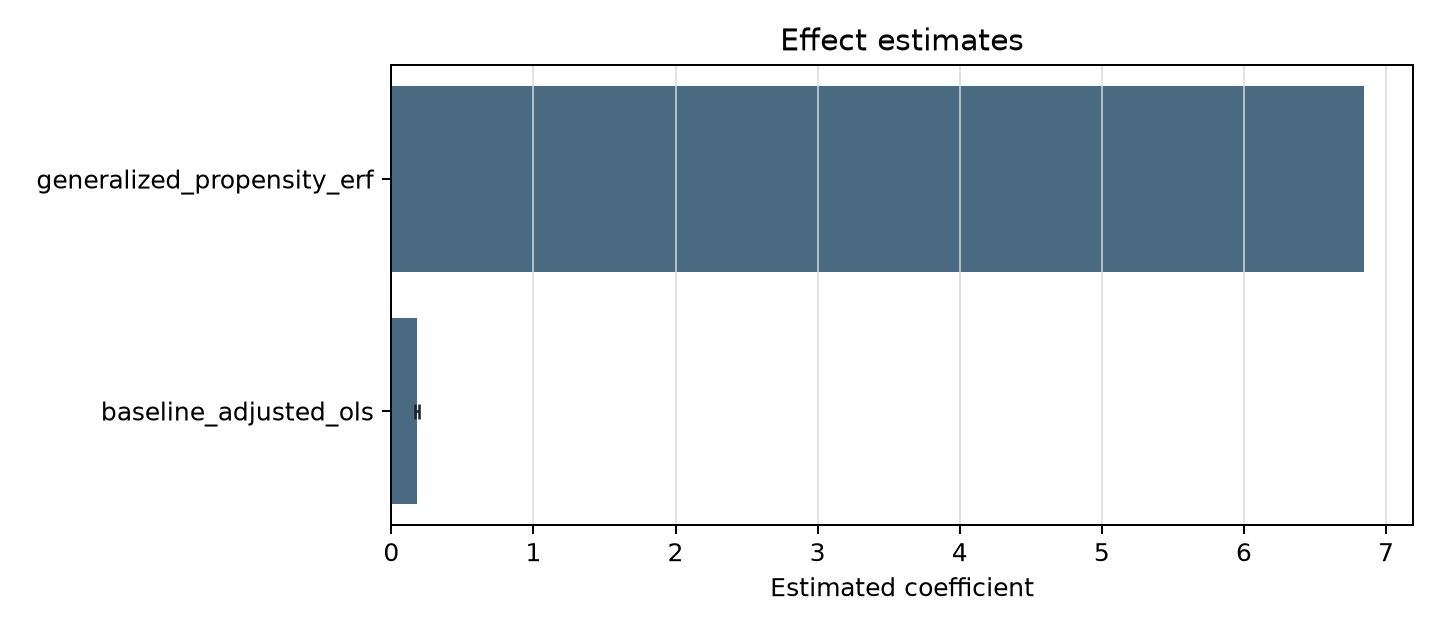

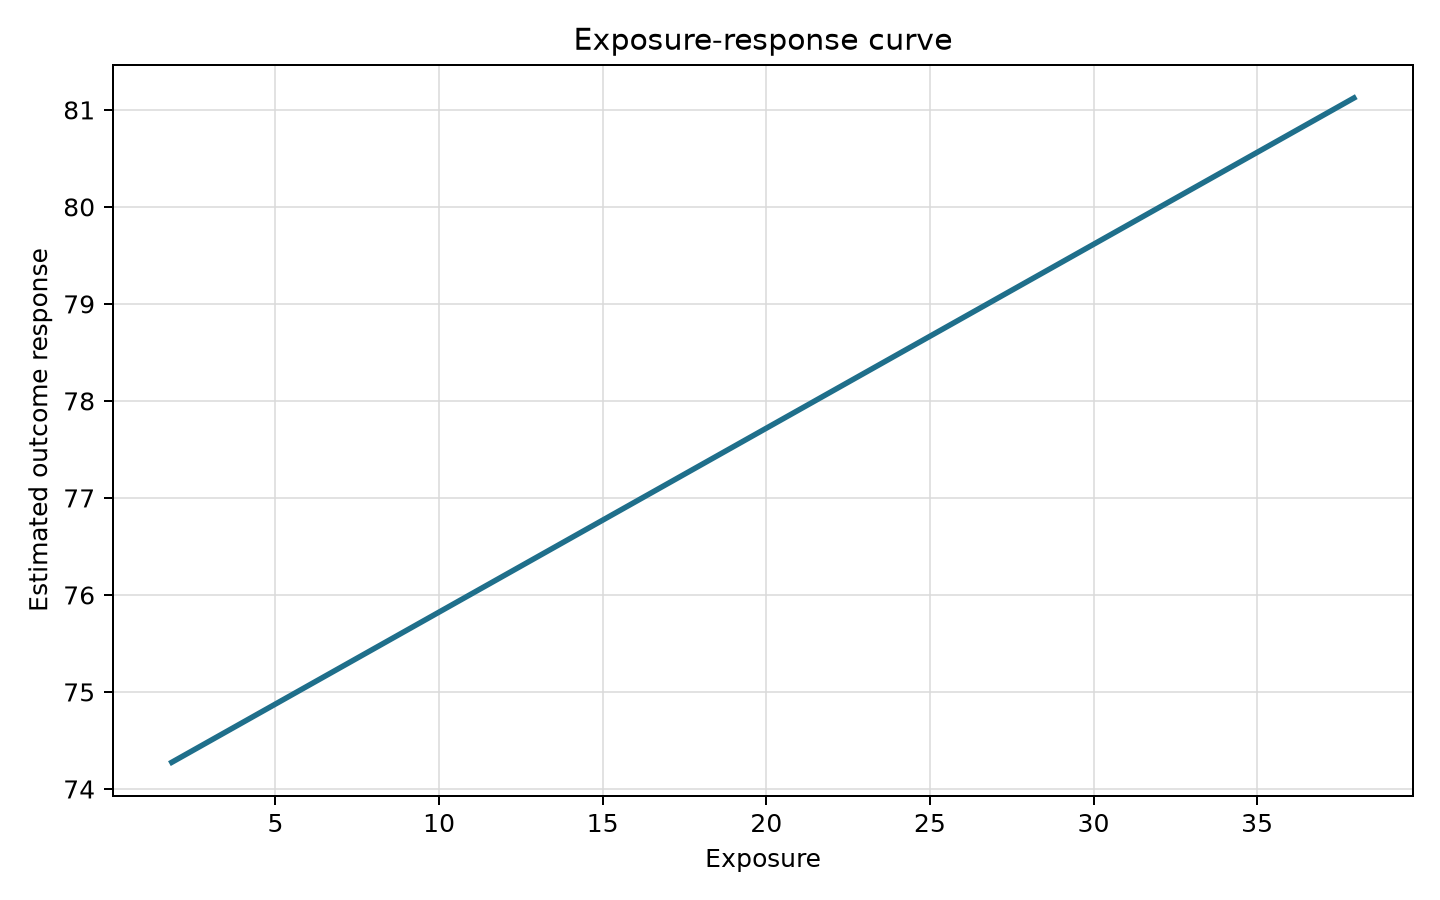

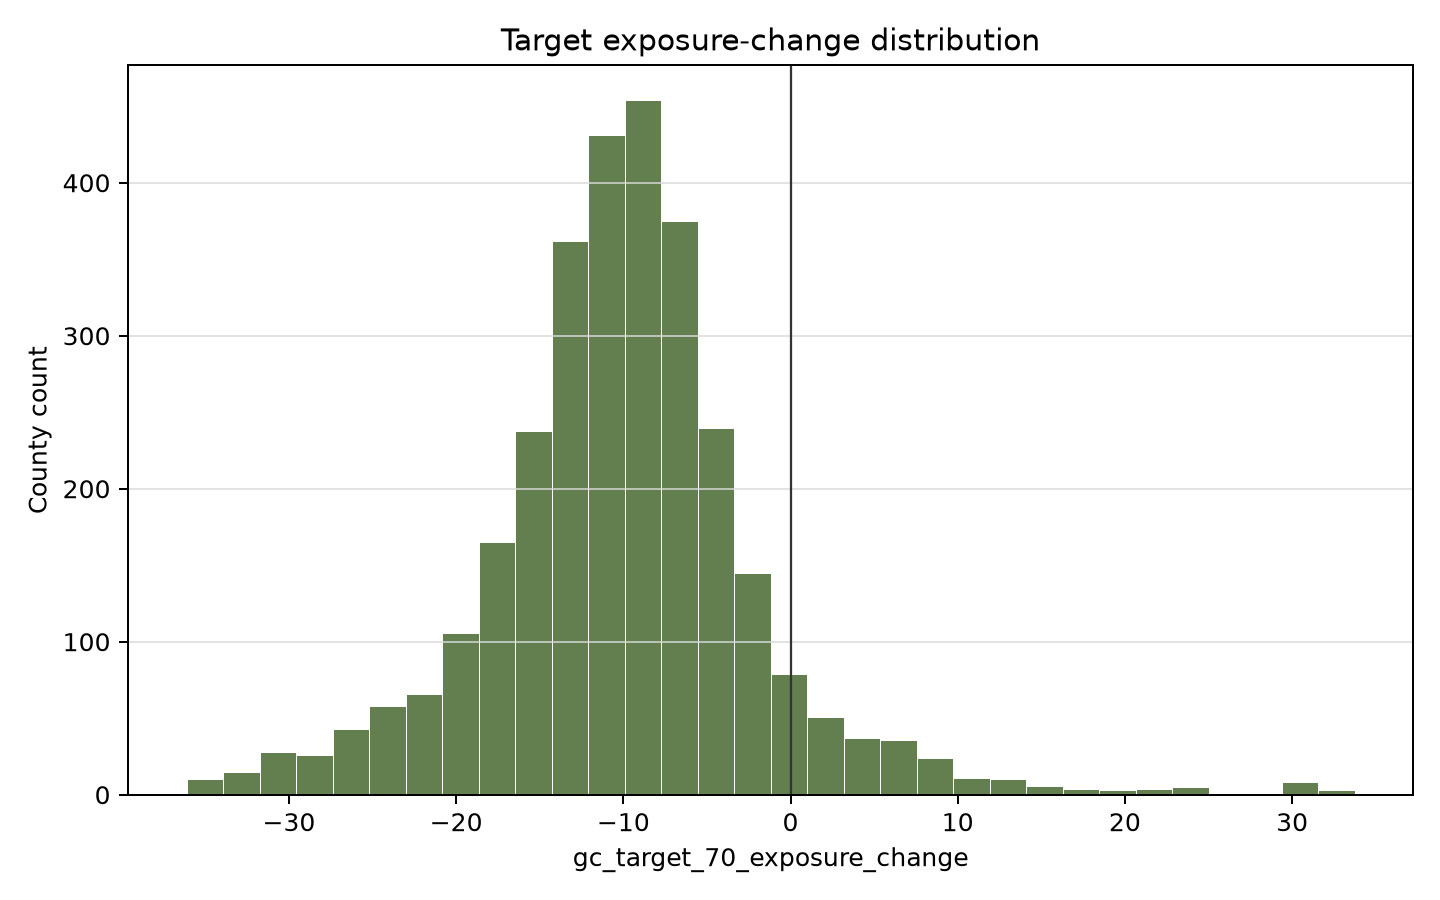

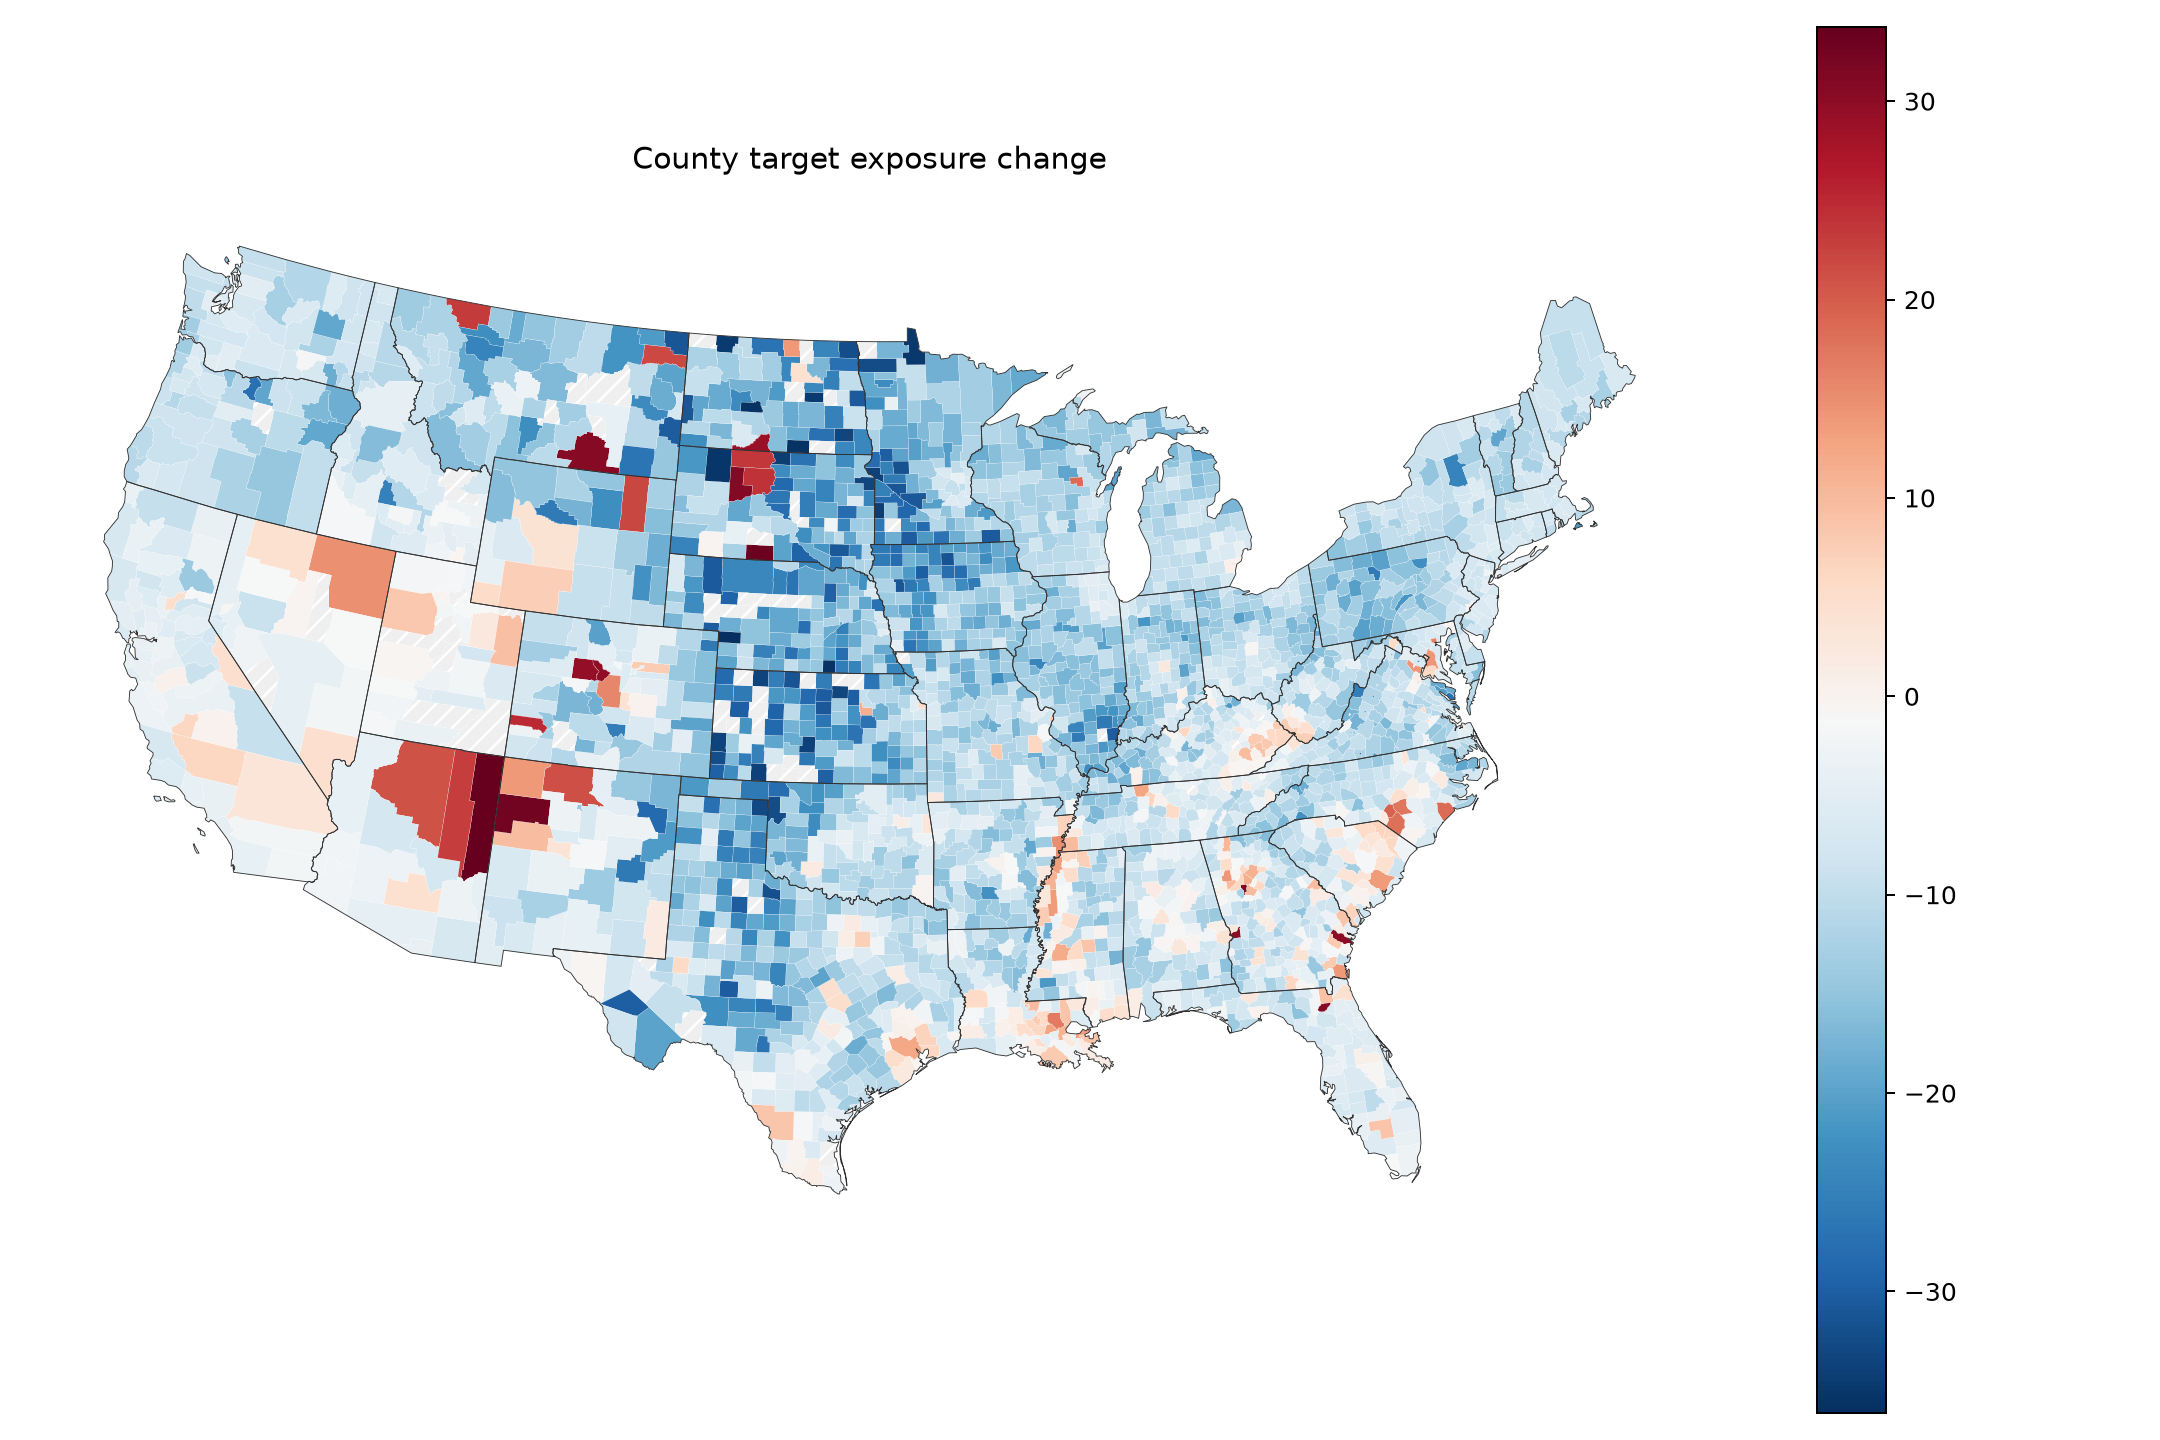

In [7]:
for key in (
    'effect_estimates_png',
    'erf_curve_png',
    'target_exposure_change_histogram_png',
    'target_exposure_change_map_png',
):
    display(Image(filename=spatial_manifest['visualizations'][key]))

In [ ]:
display(HTML(Path(spatial_manifest['visualizations']['target_exposure_change_map_html']).read_text(encoding='utf-8')))

In [ ]:
print(json.dumps({
    'analysis_manifest': str(output_dir / 'manifest.json'),
    'analysis_joined_csv': str(analysis_joined_csv),
    'spatial_outputs': spatial_manifest['spatial_files'],
    'visualizations': spatial_manifest['visualizations'],
}, indent=2, ensure_ascii=False))